### **Gradient Descent: Predicting Car Prices**

#### Objective:
Your task is to implement and use **Gradient Descent** to optimize a regression model for predicting car prices based on various features. You'll work with a real-world dataset to understand the workings of gradient descent, evaluate its performance, and compare it with other optimization techniques.


#### Dataset:
Use the **Car Price Prediction Dataset**: `data/car_price.csv`, which contains information on car features and their respective prices. Each row corresponds to a car, and the columns represent various features such as horsepower, engine size, and car dimensions. The target variable is the **car price (in dollars)**.


#### Steps to Complete:

1. **Data Loading and Exploration**  
   - Load the dataset using `pandas`.
   - Display the first few rows and explore the dataset to understand the features and their distributions.
   - Check for missing values and handle them appropriately.
   - Normalize or scale the features to ensure smooth convergence of gradient descent.

2. **Define the Linear Regression Model**  
   - Create a linear regression model with parameters (weights and biases) initialized to zero or small random values.
   - Define the **cost function** as **Mean Squared Error (MSE)**.

3. **Implement Gradient Descent**  
   - Write a custom implementation of Gradient Descent to optimize the weights and biases of the regression model:
     - Compute gradients of the cost function with respect to each parameter.
     - Update parameters iteratively using the gradient descent formula:
       $$
       \theta := \theta - \alpha \cdot \nabla J(\theta)
       $$
       where $ \alpha $ is the learning rate.

4. **Experiment with Hyperparameters**  
   - Test the algorithm with different learning rates ($ \alpha $).
   - Observe and plot the cost function values over iterations to ensure convergence.

5. **Model Evaluation**  
   - Split the dataset into **training** and **test sets**.
   - Evaluate the model's performance on both datasets using:
     - Mean Squared Error (MSE)
     - R² score
   - Compare predictions with actual values.

6. **Visualization**  
   - Plot the cost function against iterations to visualize convergence.
   - Visualize the relationship between key features (e.g., Horsepower) and predicted car prices.


#### Bonus Challenges (Optional):

1. **Mini-Batch Gradient Descent**:  
   - Modify your implementation to use mini-batches instead of the entire dataset for each gradient step.
   - Compare the performance and convergence speed of batch and mini-batch gradient descent.

2. **Stochastic Gradient Descent (SGD)**:  
   - Implement stochastic gradient descent and compare its performance with batch gradient descent.

3. **Multiple Models**:  
   - Train and evaluate the same dataset using **Scikit-learn's LinearRegression** for comparison.

4. **Polynomial Features**:  
   - Add polynomial terms for key features (e.g., horsepower squared) to improve model performance and evaluate the impact of feature engineering.


#### Deliverables:
- A Python script or Jupyter Notebook containing:
  - Code for loading and preprocessing the data.
  - Implementation of Gradient Descent for linear regression.
  - Results of model training and evaluation.
  - Visualizations of cost function convergence and predictions.
- A brief report answering:
  - How does the learning rate affect convergence?
  - What were the final MSE and R² scores?
  - Insights from comparing different optimization techniques.

1. **Data Loading and Exploration**  
   - Load the dataset using `pandas`.
   - Display the first few rows and explore the dataset to understand the features and their distributions.
   - Check for missing values and handle them appropriately.
   - Normalize or scale the features to ensure smooth convergence of gradient descent.

In [96]:
# load data

import pandas as pd
import numpy as np

df = pd.read_csv(r"data/car_price.csv")
df.head(5)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [98]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [99]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [100]:
# Drop 'car_ID' and extract car brand
df = df.drop('car_ID', axis=1)
df['CarBrand'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

# Optional: fix some misspellings
df['CarBrand'] = df['CarBrand'].replace({
    'vw': 'volkswagen', 'vokswagen': 'volkswagen',
    'porcshce': 'porsche', 'toyouta': 'toyota', 'maxda': 'mazda'
})

# Drop 'CarName' since it's no longer needed
df = df.drop('CarName', axis=1)

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True).astype('float')

df.head(5)


,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarBrand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [110]:
# Normalize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df_encoded.drop('price', axis=1)
X_scaled = scaler.fit_transform(X)

y = df_encoded['price'].values

2. **Define the Linear Regression Model**  
   - Create a linear regression model with parameters (weights and biases) initialized to zero or small random values.
   - Define the **cost function** as **Mean Squared Error (MSE)**.

3. **Implement Gradient Descent**  
   - Write a custom implementation of Gradient Descent to optimize the weights and biases of the regression model:
     - Compute gradients of the cost function with respect to each parameter.
     - Update parameters iteratively using the gradient descent formula:
       $$
       \theta := \theta - \alpha \cdot \nabla J(\theta)
       $$
       where $ \alpha $ is the learning rate.

In [111]:
# Batch Gradient Descentclass BatchGradientDescent():
from sklearn.metrics import root_mean_squared_error

class BatchGradientDescent():
    def __init__(self, lr = 0.01, tol = 0.0001, max_iter = 1000):
        self.lr = lr
        self.tol = tol
        self.max_iter = max_iter
        self.coeff_ = None
        self.intercept_ = None
        self.converged = False
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape
        X_bias = np.c_[np.ones((n_samples, 1)), X]

        # define random coeff
        coeff = np.random.randn(n_features+1)

        self.rmses = []
        for step in range(self.max_iter):
            y_pred = X_bias @ coeff
            error = y - y_pred

            self.rmses.append(root_mean_squared_error(y, y_pred))

            gradd = (-2 / n_samples) * (X_bias.T @ error)

            if np.linalg.norm(gradd*self.lr, ord=1) < self.tol:
                print(f'converget at {step} step')
                self.converged = True
                break
            
            coeff = coeff - self.lr * gradd

        if not self.converged:
            print(f'Not converget at {self.max_iter} step')

        self.coeff_ = coeff[1:]
        self.intercept_ = coeff[0]
        return self
    
    def predict(self, X):
        X = np.array(X)
        return X @ self.coeff_ + self.intercept_

5. **Model Evaluation**  
   - Split the dataset into **training** and **test sets**.
   - Evaluate the model's performance on both datasets using:
     - Mean Squared Error (MSE)
     - R² score
   - Compare predictions with actual values.

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = BatchGradientDescent(lr=0.01, tol = 1e-4, max_iter=1000)

model.fit(X_train, y_train)

# Predict
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred_test))
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))


Not converget at 1000 step
Train MSE: 1831567.050367798
Test MSE: 15919141.115000213
Train R2: 0.9692885065816019
Test R2: 0.7983489954322524


6. **Visualization**  
   - Plot the cost function against iterations to visualize convergence.
   - Visualize the relationship between key features (e.g., Horsepower) and predicted car prices.

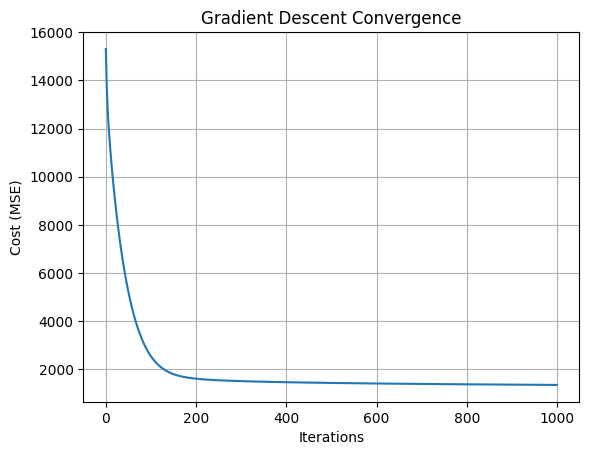

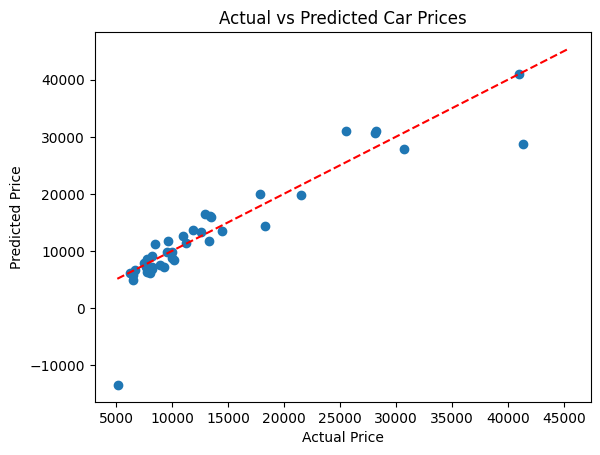

In [114]:
import matplotlib.pyplot as plt
# Cost vs Iterations
plt.plot(model.rmses)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.grid(True)
plt.show()

# Predicted vs Actual (Test Set)
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # identity line
plt.show()


In [118]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 64 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   symboling              205 non-null    float64
 1   wheelbase              205 non-null    float64
 2   carlength              205 non-null    float64
 3   carwidth               205 non-null    float64
 4   carheight              205 non-null    float64
 5   curbweight             205 non-null    float64
 6   enginesize             205 non-null    float64
 7   boreratio              205 non-null    float64
 8   stroke                 205 non-null    float64
 9   compressionratio       205 non-null    float64
 10  horsepower             205 non-null    float64
 11  peakrpm                205 non-null    float64
 12  citympg                205 non-null    float64
 13  highwaympg             205 non-null    float64
 14  fueltype_gas           205 non-null    float64
 15  aspira

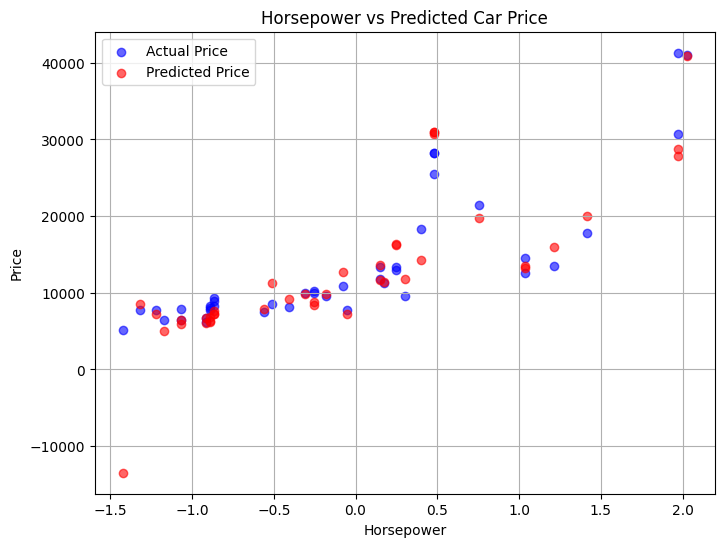

In [ ]:
# scaled horsepower values
horsepower = X_test[:,10]

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(horsepower, y_test, color='blue', label='Actual Price', alpha=0.6)
plt.scatter(horsepower, y_pred_test, color='red', label='Predicted Price', alpha=0.6)
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.title("Horsepower vs Predicted Car Price")
plt.legend()
plt.grid(True)
plt.show()
